In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Get a free API key at https://www.eia.gov/opendata/
API_KEY = "YOUR_EIA_API_KEY_HERE"

url = "https://api.eia.gov/v2/natural-gas/move/expc/data/"

european_destinations = {
    "NUS-NFR": "France",
    "NUS-NGM": "Germany",
    "NUS-NNL": "Netherlands",
    "NUS-NSP": "Spain",
    "NUS-NBE": "Belgium",
    "NUS-NIT": "Italy",
    "NUS-NUK": "UK",
    "NUS-NPL": "Poland",
    "NUS-NPO": "Portugal",
    "NUS-NGR": "Greece",
    "NUS-NLH": "Lithuania",
}

all_dfs = []

for code, country in european_destinations.items():
    params = {
        "api_key": API_KEY,
        "frequency": "monthly",
        "data[0]": "value",
        "facets[duoarea][]": code,
        "facets[process][]": "EVE",
        "start": "2018-01",
        "sort[0][column]": "period",
        "sort[0][direction]": "asc",
        "length": 5000,
    }
    response = requests.get(url, params=params)
    data = response.json()
    if data["response"]["data"]:
        df = pd.DataFrame(data["response"]["data"])
        df["country"] = country
        all_dfs.append(df)

full_df = pd.concat(all_dfs, ignore_index=True)
full_df["period"] = pd.to_datetime(full_df["period"])
full_df["value"] = pd.to_numeric(full_df["value"])


volume_df = full_df[full_df["units"] == "MMCF"].copy()
price_df = full_df[full_df["units"] == "$/MCF"].copy()

volume_df.to_csv("europe_lng_volumes.csv", index=False)
price_df.to_csv("europe_lng_prices.csv", index=False)

print(price_df.shape)
print(price_df.head())

(986, 12)
      period  duoarea area-name product product-name process  \
0 2018-10-01  NUS-NFR       FRA    EPG0  Natural Gas     EVE   
2 2018-11-01  NUS-NFR       FRA    EPG0  Natural Gas     EVE   
4 2018-12-01  NUS-NFR       FRA    EPG0  Natural Gas     EVE   
6 2019-01-01  NUS-NFR       FRA    EPG0  Natural Gas     EVE   
8 2019-03-01  NUS-NFR       FRA    EPG0  Natural Gas     EVE   

        process-name                     series  \
0  Exports by Vessel  NGM_EPG0_EVE_NUS-NFR_DMCF   
2  Exports by Vessel  NGM_EPG0_EVE_NUS-NFR_DMCF   
4  Exports by Vessel  NGM_EPG0_EVE_NUS-NFR_DMCF   
6  Exports by Vessel  NGM_EPG0_EVE_NUS-NFR_DMCF   
8  Exports by Vessel  NGM_EPG0_EVE_NUS-NFR_DMCF   

                                  series-description  value  units country  
0  Price of U.S. Liquefied Natural Gas Exports by...   6.72  $/MCF  France  
2  Price of U.S. Liquefied Natural Gas Exports by...   7.02  $/MCF  France  
4  Price of U.S. Liquefied Natural Gas Exports by...   7.47  $/MCF 

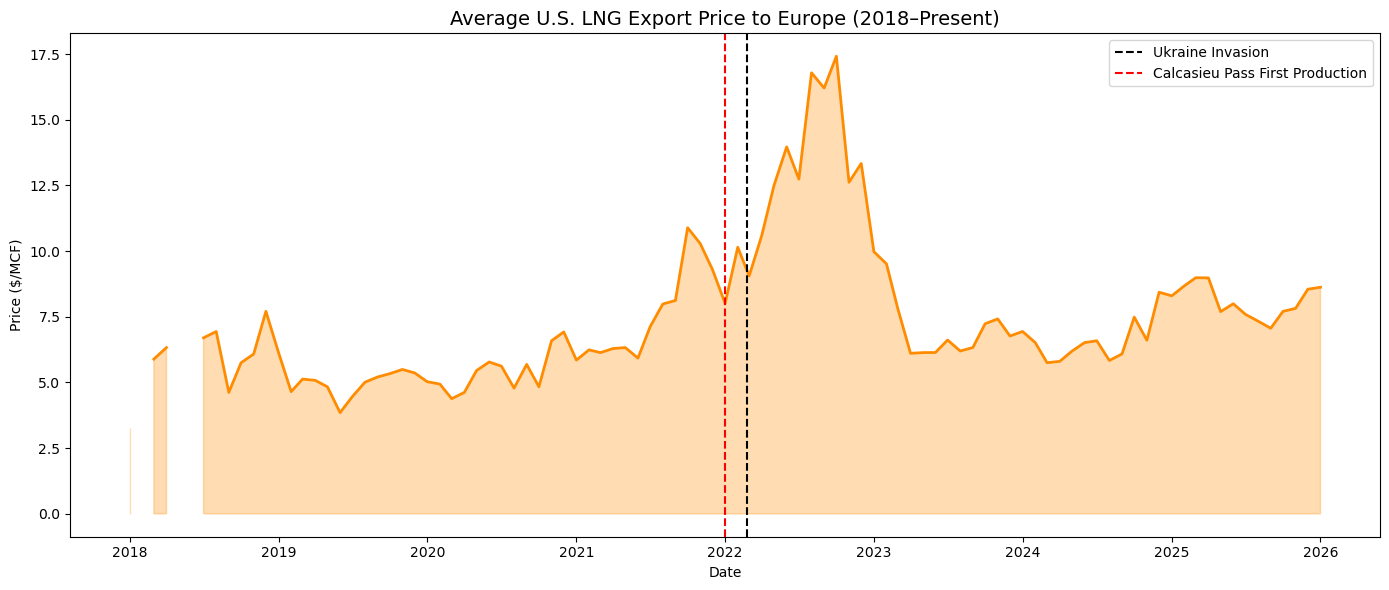

In [2]:
avg_price = price_df.groupby("period")["value"].mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(avg_price.index, avg_price.values, color="darkorange", linewidth=2)
ax.fill_between(avg_price.index, avg_price.values, alpha=0.3, color="darkorange")

ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", linewidth=1.5, label="Ukraine Invasion")
ax.axvline(pd.Timestamp("2022-01-01"), color="red", linestyle="--", linewidth=1.5, label="Calcasieu Pass First Production")

ax.set_title("Average U.S. LNG Export Price to Europe (2018–Present)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price ($/MCF)")
ax.legend()
plt.tight_layout()
plt.savefig("europe_lng_prices.png", dpi=150)
plt.show()

## The Venture Global Arbitrage

Venture Global's Louisiana based LNG export site came online in early 2022, coinciding with the largest increase in both LNG demand, as well as price ($/MCF) in LNG market history. Rather than delivering on the contracts that they agreed to at around $2-3/MMBtu, Venture Global extended their commissioning phase to last over two years.

During this specific period, the spot prices for LNG reached around $17/MCF, that is approximately 5-8x the price they had contracted. Commissioning cargos are specifically exempt from delivery obligations, materializing in a profit opportunity for Venture Global, and clear financial incentives to extend their commissioning phase for as long as they could get away with, and as long as spot prices remained at their astronomical levels.

The original contracted buyers, who had secured long-term supply at $2-3/MMBtu specifically to resell into a market trading at $17/MCF, saw that very margin captured entirely by Venture Global through the commissioning phase of Calcasieu Pass. Companies including and not limited to BP, Shell, and Edison filed arbitration claims with the clear argument being that the commissioning extension was deliberately lengthened. This case shows a clear failure in LNG contract agreements and legislation: long term contracts provide supply security to markets, and demand security for producers in normal markets, but the possibility of "legally" breaching contracts for 5-8x profits is a clear incentive against the stability and predictability of contracted markets.

As of March 2026, this arbitration dispute has produced mixed outcomes. Venture Global defeated claims by both Shell and Repsol on contract language grounds. However they lost to BP, who is seeking $3.7 billion in damages, and settled with Edison through additional deliveries of LNG. Cases from Galp and Orlen remain pending.

These mixed rulings are themselves significant. Winning on contract language is vastly different from winning based on behavior alone. This is a clear example of market structure failure, if the rule isn't written explicitly and clearly enough to win in court, the incentive is clear.